In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy import stats

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams #For changing text properties
import cmocean #A package with beautiful colormaps
from cartopy import crs as ccrs #Useful for plotting maps
import cartopy.util #Requires separate import
from cartopy.util import add_cyclic_point
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.path as mpath
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

## In-class activity: use Mid-term exam score to estimate final exam score
### Mid-term exam scores: [65,67,71,71,66,75,67,70,71,69,69]
### Final exam scores: [175,133,185,163,126,198,153,163,159,151,159]

<span style="font-size: 24px; color: red; font-weight: bold;">How can we define numpy arrays for first and exam scores? Hint: use np.array.</span>

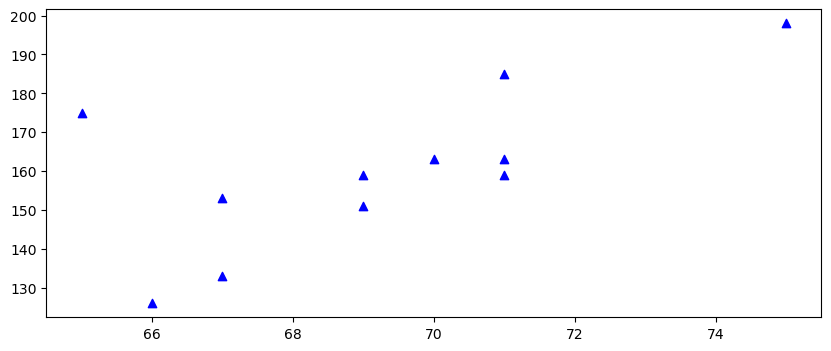

In [3]:
X = np.array([65,67,71,71,66,75,67,70,71,69,69],float)
Y = np.array([175,133,185,163,126,198,153,163,159,151,159],float)
figure = plt.figure(figsize=(10,4))
plt.scatter(X, Y, marker='^', c='b')

## Using equations in the lecture slides to calculate the slope and intercept.

In [4]:
X_mean = np.mean(X)
Y_mean = np.mean(Y)
X_anom = X-X_mean
Y_anom = Y-Y_mean
print(X_anom)

[-4.18181818 -2.18181818  1.81818182  1.81818182 -3.18181818  5.81818182
 -2.18181818  0.81818182  1.81818182 -0.18181818 -0.18181818]


In [5]:
# Now compute the covariance of X and Y
cov_XY = (np.sum(X_anom * Y_anom)) / len(X)
# Now compute the variance of X and Y
var_X = np.sum(X_anom**2) / len(X)
var_Y = np.sum(Y_anom**2) / len(Y) 
# Now compute the slope
slope = (np.sum(X_anom * Y_anom)) / np.sum(X_anom**2)
slope = cov_XY / var_X
# Now compute the intercept
intercept = Y_mean - slope * X_mean
print(slope,intercept)

4.827394209354118 -173.51336302895308


## Linear regression
### scipy.stats.linregress: Calculate a linear least-squares regression for two sets of measurements.
### https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html

In [6]:
from scipy.stats import linregress

In [7]:
# Use linregress function from scipy.stats
slope, intercept, corr_coef, p_value, std_err = linregress(X,Y)
# print the slope and intercept
print(slope,intercept)
# print the Pearson Correlation coefficient
print(corr_coef)

result = linregress(X, Y)
print(result)

4.827394209354119 -173.51336302895314
0.6630935909995176
LinregressResult(slope=4.827394209354119, intercept=-173.51336302895314, rvalue=0.6630935909995176, pvalue=0.026150151531087084, stderr=1.8164759883874757, intercept_stderr=125.76450515624121)


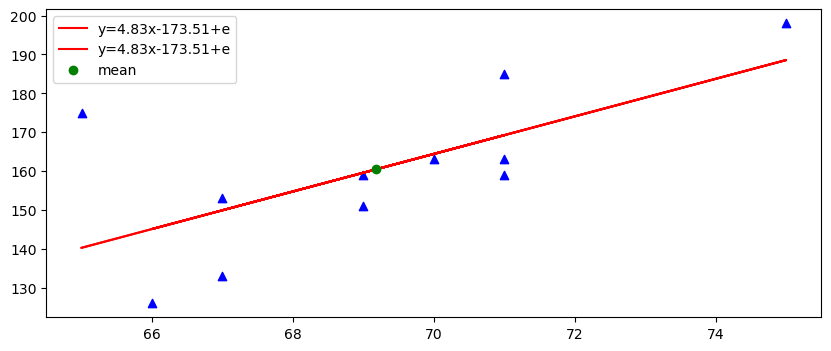

In [8]:
figure = plt.figure(figsize=(10,4))
plt.scatter(X, Y, marker='^', c='b')
# Add the linear regression line to the scatterplot
# The x-axis is X, and the y-axis is the predicted y
yhat = intercept + slope*X
plt.plot(X, intercept + slope*X, 'r', label='y='+f"{slope:.2f}"+'x'+f"{intercept:.2f}"+'+e')
plt.plot(X, yhat, 'r', label='y='+f"{slope:.2f}"+'x'+f"{intercept:.2f}"+'+e')

# Add the dot represent the mean of x and the mean of y to the scatterplot
X_mean = np.mean(X)
Y_mean = np.mean(Y)
plt.plot(X_mean, Y_mean, marker='o', linestyle='', color='g', label='mean')

plt.legend()
plt.show()

In [9]:
# test some properties of linear regression
Yhat = intercept+slope*X
error = Y-Yhat
print(np.mean(error))
print('mean of observed Y values: ',np.mean(Y))
print('mean of predicted Y values: ',np.mean(Yhat))

2.5837917664003644e-15
mean of observed Y values:  160.45454545454547
mean of predicted Y values:  160.45454545454547


## Calculate SSE, SSR, and SST and the coefficient of determination $R^2$

In [10]:
# Define a function
def var_anlys(x,y,slope,intercept):
    """Calculate SSE for a guessed linear regression line
    
    Input parameter:
        x,y (1d numpy array): 
            the numpy arrays with the data points
        slope (float): 
            value for the regression line slope
        
        intercept (float): intercept of the line
    Returns:
        The SSE value (float)
        The SST value (float)
        The SSR value (float)
        The R^2 value (float)
    """
    yhat = intercept+slope*x
    error = y-yhat
    SSE = 0
    for e in error:
        SSE = SSE+e**2

    SST = 0
    for i in y:
        SST = SST+(i-np.mean(y))**2

    SSR = 0
    for i in yhat:
        SSR = SSR+(i-np.mean(y))**2

    R2 = SSR/SST
    R2_1 = 1-SSE/SST
    return SSE,SST,SSR,R2,R2_1

In [11]:
sse,sst,ssr,R2,R2_1 = var_anlys(X,Y,slope,intercept)
print('SSE: ',sse)
print('SST: ',sst)
print('SSR: ',ssr)
print('R^2: ',R2)
print('R^2: ',R2_1)

SSE:  2424.295100222717
SST:  4326.727272727273
SSR:  1902.4321725045581
R^2:  0.43969311042463627
R^2:  0.43969311042463577
